<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 25.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.0 MB/s eta 0:00:00


In [3]:
import fastai
from fastai import *
from fastai.vision import *
from fastai.vision.all import *
from fastai.losses import MSELossFlat, CrossEntropyLossFlat
import timm
import PIL
from torchvision import transforms

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

## Balanceo

In [6]:
tam = df.loc[df["cancer"] == 1]["image_id"].size

In [7]:
np.random.seed(0)
images = df.loc[df["cancer"] == 1]["image_id"]
images = np.concatenate((images, np.random.choice(df.loc[df["cancer"] == 0]["image_id"], tam)))
images.size

2316

In [8]:
dfb = df.loc[df["image_id"].isin(images)].copy()

In [9]:
dfb["cancer"].value_counts()

1    1158
0    1147
Name: cancer, dtype: int64

In [10]:
import os
import shutil

p_under = path/"undersampled"

if not os.path.isdir(p_under):
    os.mkdir(p_under)

for index, row in dfb.iterrows():
    patient = row["patient_id"]
    if not os.path.isdir(p_under/str(patient)):
        os.mkdir(p_under/str(patient))
    image = row["image_id"]
    src = imagesPath/str(patient)/(str(image)+'.jpg')
    dst = p_under/str(patient)/(str(image)+'.jpg')
    shutil.copyfile(src, dst)

In [11]:
def cadena3(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func3(fname):
    return dfb.loc[dfb['image_id'] == int(cadena3(fname.name))]['cancer'].values[0]

## Multi-Task

In [12]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dfb["density"] = enc.fit_transform(np.array(dfb["density"]).reshape(-1,1))

In [13]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3, weights="uniform")
dfb[dfb.columns[5:]] = imputer.fit_transform(dfb[dfb.columns[5:]])

In [14]:
dfb[dfb.columns[5:]] = dfb[dfb.columns[5:]].astype(int)

In [15]:
label = []
for i, row in dfb.iterrows():
    edad = str(int(row["age"]))
    cancer = str(row["cancer"])
    densidad = str(row["density"])
    if '.' in densidad:
        densidad = densidad[0]
    label.append(edad + ' ' + cancer + ' ' + densidad)
dfb["label"] = label
dfb

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,label
63,2,10106,190315990,R,MLO,57,0,0,0,0,0,1,21,0,57 0 1
87,1,10130,388811999,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
88,1,10130,613462606,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
89,1,10130,1360338805,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
90,1,10130,1672636630,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54596,2,9851,1434430689,L,CC,58,1,1,0,0,0,1,48,0,58 1 1
54599,2,9852,948754725,L,CC,58,0,0,0,0,0,1,29,0,58 0 1
54627,1,9894,1991772614,R,CC,50,0,1,0,0,0,1,49,1,50 0 1
54636,2,990,837618473,R,MLO,57,0,0,0,1,0,1,48,0,57 0 1


In [16]:
class MultiTaskDataset():
    def __init__(self, df, tfms, size=64):
        self.paths = []
        for index, row in df.iterrows():
            patient = row["patient_id"]
            image = row["image_id"]
            path = p_under/str(patient)/(str(image) + '.jpg')
            self.paths.append(path)
        self.labels = list(df["label"])
        self.tfms = tfms
        self.size = size
        self.train = df.copy()
        self.norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #imagenet stats

    def __len__(self): return len(self.paths)

    def __getitem__(self,idx):
        #dealing with the image
        img = PIL.Image.open(self.paths[idx]).convert('RGB')
        img = img.resize((256, 256))
        t = torch.Tensor(np.array(img))
        t = t.permute(2, 0, 1).float() / 255.0
        transform = transforms.ToPILImage()
        img = PILImage(PILImage.create(transform(t)))
        img = self.tfms.encodes(img)
        transform = transforms.Compose([transforms.ToTensor()])
        img = self.norm(transform(img))
        #dealing with the labels
        labels = self.labels[idx].split(" ")
        age = torch.tensor(float(labels[0]), dtype=torch.float32)
        cancer = torch.tensor(int(labels[1]), dtype=torch.int64)
        density = torch.tensor(int(labels[2]), dtype=torch.int64)

        return img, (age.log_() / 4.75, cancer, density)

    def show(self,idx):
        x, y = self.__getitem__(idx)
        age, cancer, density = y
        stds = np.array([0.229, 0.224, 0.225])
        means = np.array([0.485, 0.456, 0.406])
        img = ((x.numpy().transpose((1, 2, 0)) * stds + means) * 255).astype(np.uint8)
        plt.imshow(img)
        plt.title("{} {} {}".format(int(age.mul_(4.75).exp_().item()), cancer.item(), density.item()))

In [87]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(dfb, test_size=0.2)

tfms = aug_transforms()
tdset = MultiTaskDataset(train, tfms[0], size=64)
vdset = MultiTaskDataset(test, tfms[1], size=64)
data = DataLoaders.from_dsets(tdset, vdset, batch_size=4, shuffle=True, device=torch.device('cuda'))

In [18]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024, 1, ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024, 2, ps=ps)
        self.fc3 = create_head(1024, 11, ps=ps)

    def forward(self, x):
        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [19]:
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, task_num):
        super(MultiTaskLossWrapper, self).__init__()
        self.task_num = task_num
        self.log_vars = nn.Parameter(torch.zeros((task_num)))

    def forward(self, preds, label):

        mse, crossEntropy = MSELossFlat(), CrossEntropyLossFlat()

        loss0 = mse(preds[0], label[0])
        loss1 = crossEntropy(preds[1], label[1])
        loss2 = crossEntropy(preds[2], label[2])

        precision0 = torch.exp(-self.log_vars[0])
        loss0 = precision0 * loss0 + self.log_vars[0]

        precision1 = torch.exp(-self.log_vars[1])
        loss1 = precision1 * loss1 + self.log_vars[1]

        precision2 = torch.exp(-self.log_vars[2])
        loss2 = precision2 * loss2 + self.log_vars[2]

        return loss0 + loss1 + loss2

In [20]:
from sklearn.metrics import f1_score
def rmse_age(preds, labels): return rmse(preds[0], labels[0])
def f1_cancer(preds, labels):
    pred = preds[1].cpu()
    pred = np.array(pred)
    plist = []
    for i in range(len(pred)):
        if np.sum(pred[i]) > 0:
            plist.append(1)
        else:
            plist.append(0)
    return f1_score(np.array(plist), labels[1].cpu(), zero_division=0)
def acc_density(preds, labels): return accuracy(preds[2], labels[2])

metrics = [rmse_age, f1_cancer, acc_density]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_func = MultiTaskLossWrapper(3).to(device) #just making sure the loss is on the gpu

## Modelos Multi-Task

### ConvNext

In [21]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.355607,1.850918,0.050756,0.216052,0.605206,02:38


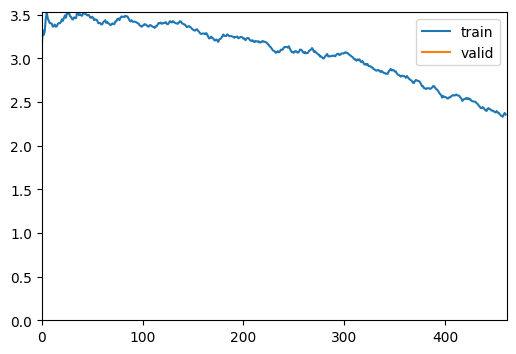

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,1.833839,1.636318,0.072294,0.326247,0.611714,02:27
1,1.801419,1.648306,0.064975,0.457349,0.603037,02:27
2,1.825779,1.787393,0.044089,0.084309,0.533623,02:27
3,1.751801,1.641395,0.047468,0.364921,0.598698,02:27
4,1.679158,2.031094,0.037684,0.483834,0.449024,02:27
5,1.704323,1.553179,0.036986,0.446896,0.691974,02:26
6,1.731616,1.770174,0.036708,0.456069,0.511931,02:27
7,1.614940,1.540555,0.036002,0.412540,0.655098,02:27
8,1.588724,1.510892,0.034972,0.332466,0.674620,02:27
9,1.586835,1.523134,0.034422,0.481521,0.659436,02:27


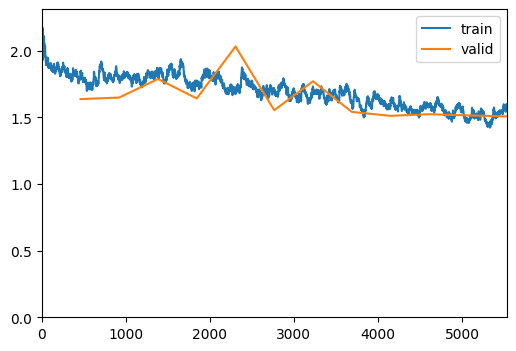

In [22]:
model = MultiTaskModel(convnext_base(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=ShowGraphCallback(), metrics=metrics)
learn.fine_tune(12, base_lr=1e-3)

## Procesamiento de datos

In [23]:
from sklearn import preprocessing, model_selection, metrics

np.random.seed(0)

train_ratio = 0.7
validation_ratio = 0.1
test_ratio = 0.2

X = dfb.loc[::, ["age", "density"]].copy()
y = dfb.loc[::, "cancer"].copy()

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 1 - train_ratio)
X_val, X_test, y_val, y_test = model_selection.train_test_split(X_test, y_test, test_size = test_ratio / (test_ratio + validation_ratio))

normalizar = preprocessing.StandardScaler()
X_train_norm = normalizar.fit_transform(X_train)
X_val_norm = normalizar.fit_transform(X_val)
X_test_norm = normalizar.fit_transform(X_test)

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
def mostrar_resultados(nombre, modelo, X_val, y_val):
    print('> ', nombre)

    prediccion = modelo.predict(X_val)
    score = round(modelo.score(X_val, y_val) * 100, 2)
    print('>  Accuracy: {}\n'.format(score))

    matriz = metrics.confusion_matrix(y_val, prediccion)
    print(matriz)
    plt.rcParams["figure.figsize"] = (8, 6)
    print(metrics.classification_report(y_val, prediccion, zero_division=0))

### Conjunto de Test

In [26]:
X_train = pd.concat([X_train, X_val])
y_train = pd.concat([y_train, y_val])

In [27]:
rf = RandomForestClassifier(random_state = 0, bootstrap = True, criterion = 'entropy', max_features = None)
rf.fit(X_train, y_train.values.ravel())
mostrar_resultados("Random Forest", rf, X_test, y_test)

>  Random Forest
>  Accuracy: 72.08

[[167  66]
 [ 63 166]]
              precision    recall  f1-score   support

           0       0.73      0.72      0.72       233
           1       0.72      0.72      0.72       229

    accuracy                           0.72       462
   macro avg       0.72      0.72      0.72       462
weighted avg       0.72      0.72      0.72       462



## Unión de modelos

In [28]:
train = X_train.index.values.tolist()
test = X_test.index.values.tolist()

In [80]:
preds, targs = learn.get_preds()

In [112]:
preds

[tensor([[0.8529],
         [0.8462],
         [0.8781],
         [0.8634],
         [0.8642],
         [0.8580],
         [0.8582],
         [0.8539],
         [0.8767],
         [0.8800],
         [0.8552],
         [0.8574],
         [0.8495],
         [0.8680],
         [0.8487],
         [0.8451],
         [0.8698],
         [0.8674],
         [0.8567],
         [0.8691],
         [0.8505],
         [0.8780],
         [0.8837],
         [0.8833],
         [0.8489],
         [0.8588],
         [0.8671],
         [0.8708],
         [0.8633],
         [0.8534],
         [0.8564],
         [0.8544],
         [0.8478],
         [0.8664],
         [0.8594],
         [0.8723],
         [0.8678],
         [0.8623],
         [0.8412],
         [0.8563],
         [0.8661],
         [0.8658],
         [0.8788],
         [0.8533],
         [0.8786],
         [0.8639],
         [0.8717],
         [0.8428],
         [0.8614],
         [0.8595],
         [0.8609],
         [0.8667],
         [0.

In [113]:
targs

(tensor([0.7967, 0.8014, 0.8852, 0.8193, 0.8359, 0.8512, 0.8359, 0.8756, 0.8788,
         0.9089, 0.8359, 0.8236, 0.7766, 0.8512, 0.8398, 0.8398, 0.8398, 0.8914,
         0.8060, 0.8689, 0.8788, 0.8852, 0.8548, 0.8318, 0.8474, 0.7713, 0.8474,
         0.7918, 0.9225, 0.8106, 0.8359, 0.8236, 0.8584, 0.8014, 0.7658, 0.9033,
         0.8974, 0.9426, 0.8150, 0.8106, 0.9089, 0.9303, 0.9199, 0.8236, 0.9378,
         0.9089, 0.9061, 0.7918, 0.8014, 0.8852, 0.8852, 0.8689, 0.8883, 0.8193,
         0.9061, 0.8788, 0.8788, 0.8654, 0.8820, 0.9145, 0.8974, 0.8150, 0.8788,
         0.8722, 0.9061, 0.8359, 0.8689, 0.8584, 0.8883, 0.8654, 0.9145, 0.8654,
         0.8820, 0.8584, 0.7918, 0.8974, 0.9004, 0.8852, 0.8914, 0.9061, 0.8914,
         0.8689, 0.8436, 0.8883, 0.8106, 0.8788, 0.8689, 0.9426, 0.8820, 0.8852,
         0.8756, 0.9004, 0.8014, 0.8620, 0.8722, 0.8788, 0.8584, 0.8474, 0.8236,
         0.8548, 0.9277, 0.8654, 0.8788, 0.8883, 0.8436, 0.8654, 0.8689, 0.9061,
         0.9251, 0.8150, 0.9